# Welcome to the `scatterscale` demo!

`scatterscale` is a package that can help you automatically choose the best normalizing scale for the colorbar that represents the third dimension of a scatterplot. Out of the native `matplotlib.colors.Norm` colorbar scaling options, `scatterscale` chooses the one which shows the greatest contrast. In order for `scatterscale` to produce the best visual contrast, the colormap used must be perceptually uniform. We recommend using either `matplotlib`'s perceptually uniform colormaps (viridis, plasma, inferno, magma, and cividis), or one of the many perceptually uniform colormaps available in the `cmasher` package.

This notebook requires you to pip install `scatterscale` before running it.

In [3]:
# some required import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scatterscale import handle_outliers
from scatterscale import get_scatterscale

In this tutorial, we will represent data from the JWST Advanced Deep Extragalactic Survey (JADES, Eisenstein et al. 2026) Data Release 5 photometric catalog (Robertson et al. 2026). The required data file is provided alongside this notebook.

In [4]:
# fetch the demo data
data = pd.read_csv('jades_dr5_demo_data.csv')

In [5]:
data

,ID,F090W_KRON,F182M_KRON,F200W_KRON,F444W_KRON,photoz
0,490,44.891501,145.712765,72.365925,116.064542,2.80
1,519,45.079392,33.500378,43.180997,25.601965,0.76
2,522,-26.214179,30.203677,16.456006,30.149901,3.49
3,549,105.312790,138.397255,104.310861,89.744492,2.42
4,550,47.483395,75.022954,51.581375,28.120277,0.72
...,...,...,...,...,...,...
89725,3301718,-2.387266,4.853579,1.150072,26.270901,8.61
89726,3301754,18.730689,-40.162270,4.768035,41.189591,4.99
89727,3301987,-23.492848,-0.999764,4.515437,33.786540,4.22
89728,3302027,9.594798,10.986778,10.878755,20.080720,17.30


For each JADES galaxy, we want to plot its measured fluxes in two filters against each other, and color each datapoint by a third data column.

In [6]:
def comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_data_key, xaxis_data_key, yaxis_data_key):
    """
    Compare unscaled colors to scatterscale colors by plotting them alongside each other.

    Args

        colorbar_data (1d array): values to use to make the colorbar.

        xaxis_data (1d array): x axis array values.

        yaxis_data (1d array): y axis array values.

        colorbar_data_key (str): name and units of the data to use to make the colorbar.

        xaxis_data_key (str): name and units of the x axis data.

        yaxis_data_key (str): name and units of the y axis data.

    Returns

        None.
    """
    
    plt.style.use("dark_background")
    fig, ax = plt.subplots(1,2, figsize=(10, 4))

    # without any scaling
    plot0 = ax[0].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colors.NoNorm(np.nanmin(colorbar_data), np.nanmax(colorbar_data)), cmap="viridis", alpha=0.3, s=2)
    ax[0].set_title("No scaling")
    ax[0].set_xlabel(f"{xaxis_data_key}")
    ax[0].set_ylabel(f"{yaxis_data_key}")
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    colorbar0 = fig.colorbar(plot0, ax=ax[0], label=colorbar_data_key)
    colorbar0.solids.set(alpha=1)

    ## use scatterscale to get the best normalization for the colorbar
    colorbar_norm = get_scatterscale(colorbar_data)

    # with scatterscale's optimal scaling
    plot1 = ax[1].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colorbar_norm, cmap="viridis", alpha=0.3, s=2)
    ax[1].set_title("With scatterscale scaling")
    ax[1].set_xlabel(f"{xaxis_data_key}")
    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    colorbar1 = fig.colorbar(plot1, ax=ax[1], label=colorbar_data_key)
    colorbar1.solids.set(alpha=1)

    plt.tight_layout()
    plt.show()

    return

### Demonstrations!

Best scaling: SymLog (linthresh=0.1)


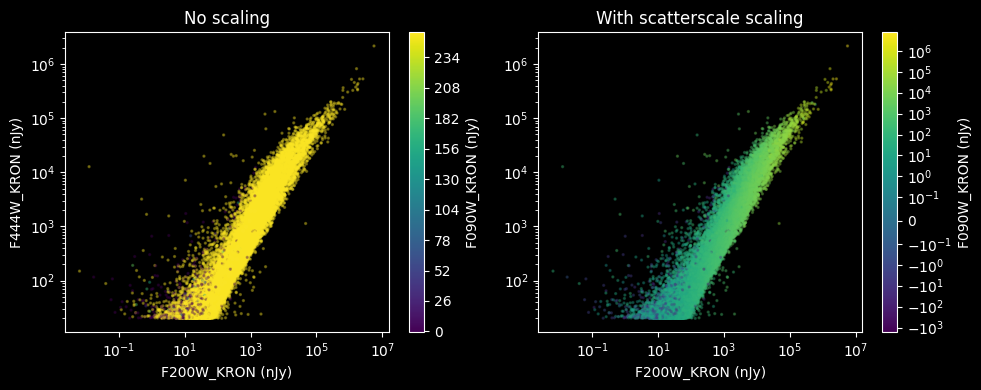

In [7]:
colorbar_data, colorbar_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
xaxis_data, xaxis_key = data["F200W_KRON"].values, "F200W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

In the above example,  `scatterscale` chooses the SymLog scaling as the best colorbar normalization for F090W_KRON. It's clear that there is a lot more contrast in the right figure!

Best scaling: SymLog (linthresh=0.1)


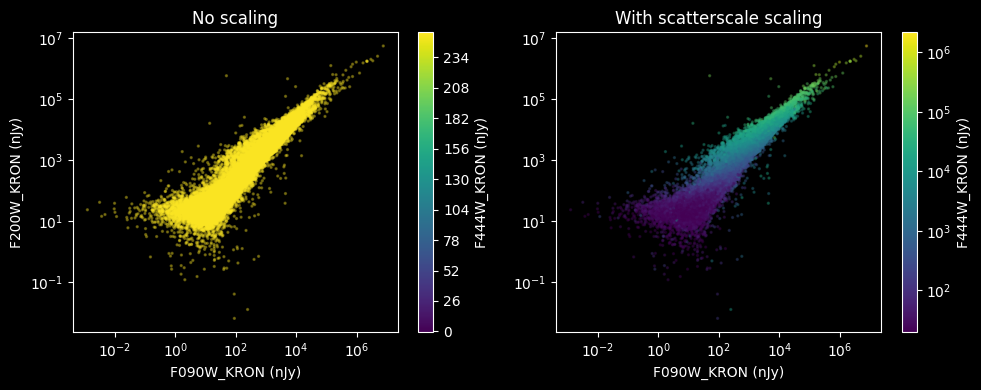

In [8]:
colorbar_data, colorbar_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F200W_KRON"].values, "F200W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

SymLog is once again the best scaling for the F444W_KRON filter.

Best scaling: Log


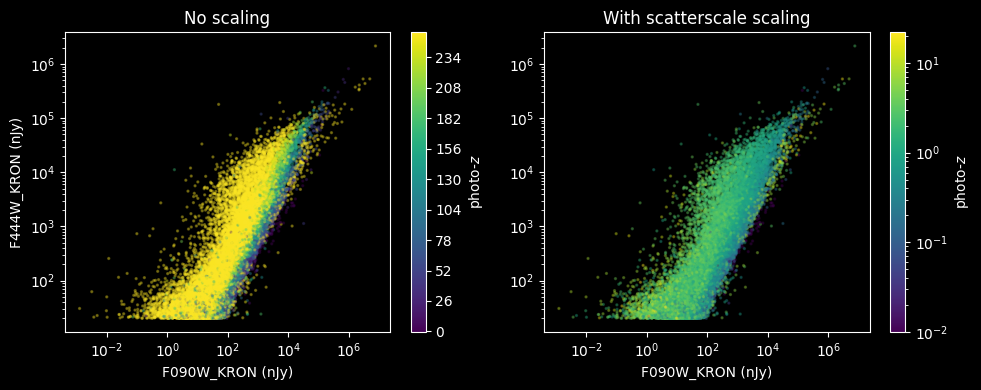

In [9]:
colorbar_data, colorbar_key = data["photoz"].values, r"photo-$z$"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

For photo-$z$, the best scaling is a Log. It allows us to see greater contrast on the left side of the distribution.

Best scaling: No normalization


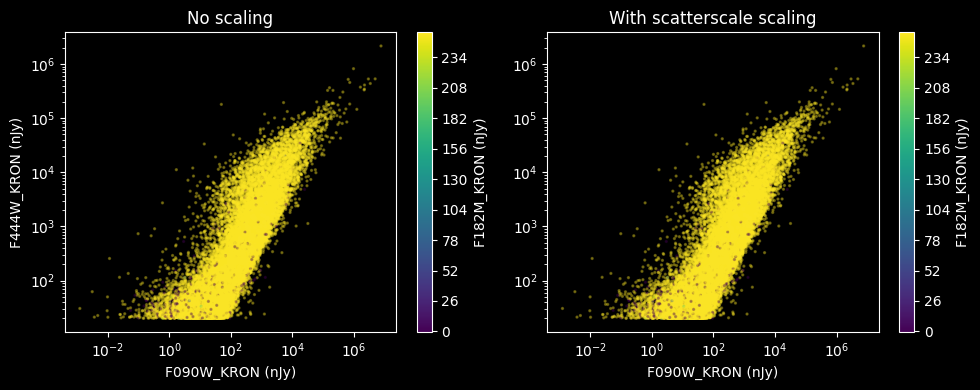

In [10]:
colorbar_data, colorbar_key = data["F182M_KRON"].values, "F182M_KRON (nJy)"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

For the F182M_KRON filter, `scatterscale` chooses that no normalization is the best normalization scale. However, there is clearly not much contrast in the not normalized plot. The reason for this is outliers - there are a few points with extremely (unrealistically) high values which are skewing the distribution!

## Handling outliers

In some cases, you may want to "handle" outlier values in the third flux measurement which would significantly disrupt the visual contrast we're seeking. The handle_outliers function allows you to either mask out outlier values completely, or to reassign them to value of the boundary above which they are considered an outlier. The default handling is to mask out outliers, since piling up outliers can cause the plot to look strange in some cases.

In [11]:
def outlier_comparison_plot(colorbar_raw_data, colorbar_masked_data, xaxis_data, yaxis_data, colorbar_data_key, xaxis_data_key, yaxis_data_key):
    """
    Compare raw data with unscaled colors to outlier-handled data with and without scatterscale colors by plotting them alongside each other.

    Args

        colorbar_raw_data (1d array): raw values to use to make the colorbar, before outlier detection.

        colorbar_masked_data (1d array): outlier-masked values to use to make the colorbar.

        xaxis_data (1d array): x axis array values.

        yaxis_data (1d array): y axis array values.

        colorbar_data_key (str): name and units of the data to use to make the colorbar.

        xaxis_data_key (str): name and units of the x axis data.

        yaxis_data_key (str): name and units of the y axis data.

    Returns

        None.
    """

    fig, ax = plt.subplots(1,3, figsize=(15, 4), sharey=True)
    plt.style.use("dark_background")

    # without any scaling, raw data
    plot0 = ax[0].scatter(xaxis_data, yaxis_data, c=colorbar_raw_data, norm=colors.NoNorm(np.nanmin(colorbar_raw_data), np.nanmax(colorbar_raw_data)), cmap="viridis", alpha=0.3, s=2)
    ax[0].set_title("Raw data, no scaling")
    ax[0].set_xlabel(f"{xaxis_data_key}")
    ax[0].set_ylabel(f"{yaxis_data_key}")
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    colorbar0 = fig.colorbar(plot0, ax=ax[0], label=colorbar_data_key)
    colorbar0.solids.set(alpha=1)

    # without any scaling, outliers removed
    plot1 = ax[1].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colors.NoNorm(np.nanmin(colorbar_masked_data), np.nanmax(colorbar_masked_data)), cmap="viridis", alpha=0.3, s=2)
    ax[1].set_title("Outliers removed, no scaling")
    ax[1].set_xlabel(f"{xaxis_data_key}")
    ax[1].set_ylabel(f"{yaxis_data_key}")
    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    colorbar1 = fig.colorbar(plot1, ax=ax[1], label=colorbar_data_key)
    colorbar1.solids.set(alpha=1)

    ## use scatterscale to get the best normalization for the colorbar
    colorbar_norm = get_scatterscale(colorbar_data)

    # with scatterscale's optimal scaling
    plot2 = ax[2].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colorbar_norm, cmap="viridis", alpha=0.3, s=2)
    ax[2].set_title("Outliers removed, with scatterscale scaling")
    ax[2].set_xlabel(f"{xaxis_data_key}")
    ax[2].set_xscale("log")
    ax[2].set_yscale("log")
    colorbar2 = fig.colorbar(plot2, ax=ax[2], label=colorbar_data_key)
    colorbar2.solids.set(alpha=1)

    plt.tight_layout()
    plt.show()

    return

handle_outliers() naively fits a Gaussian to the colorbar values distribution, and clips out any values beyond a certain value of sigma away from the median. You can control how aggressively you want to clip outliers by modifying the sigma_value variable.

80 upper outliers found.
0 lower outliers found.
Best scaling: Asinh (linear_width=1)


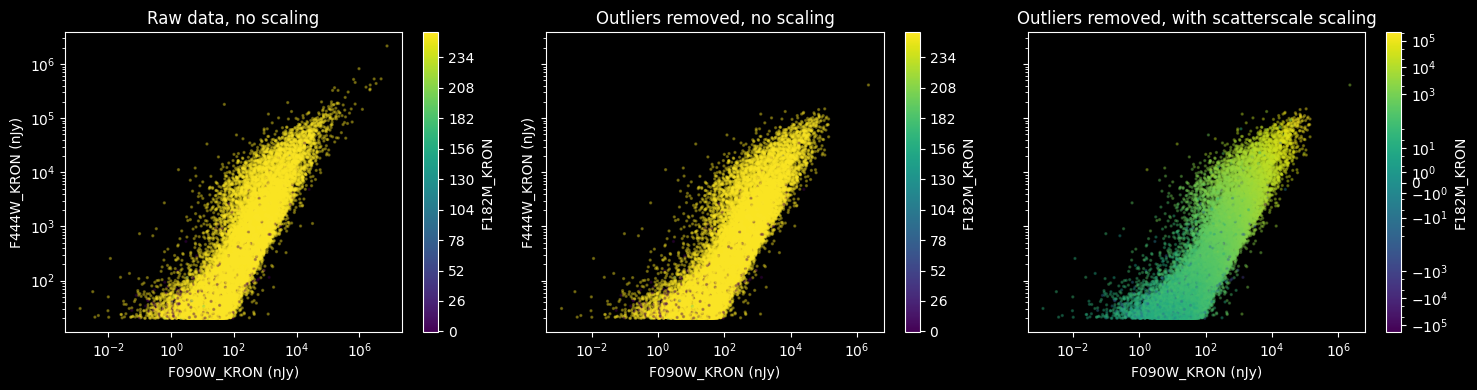

In [12]:
F182M_KRON_outliers_masked = handle_outliers(data["F182M_KRON"].values, sigma_value=5, treatment="mask_out", verbose=True)

colorbar_data, colorbar_key = F182M_KRON_outliers_masked, "F182M_KRON"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

outlier_comparison_plot(data["F182M_KRON"].values, colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

That's so much better!

Here is one more example of how removing outliers improves the visual contrast with `scatterscale`.

299 upper outliers found.
0 lower outliers found.
Best scaling: SymLog (linthresh=0.1)


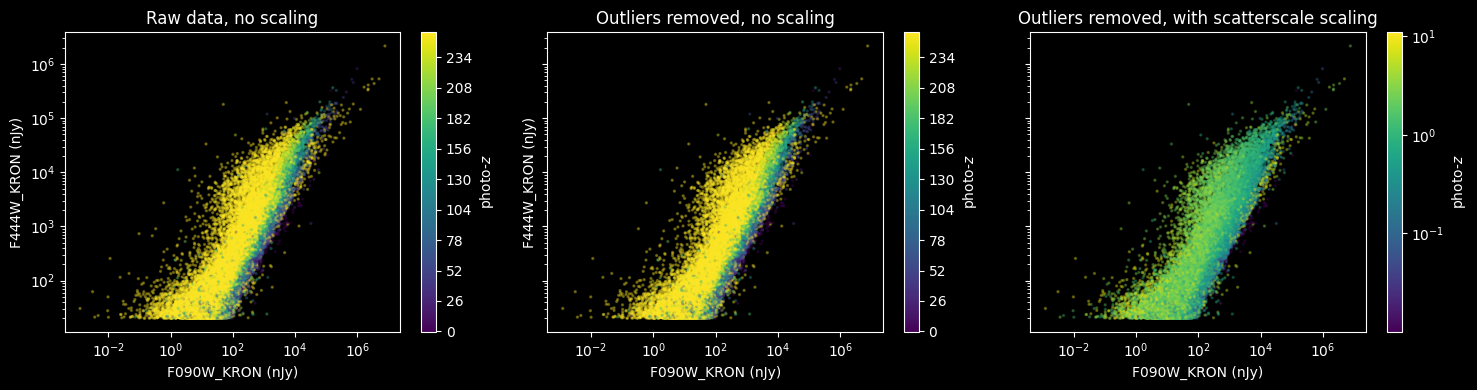

In [13]:
photoz_outliers_masked = handle_outliers(data["photoz"].values, sigma_value=5, treatment="mask_out", verbose=True)

colorbar_data, colorbar_key = photoz_outliers_masked, r"photo-$z$"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

outlier_comparison_plot(data["photoz"].values, colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)